Importing necesary packages and libraries

In [312]:
import numpy as np
import pylab as pl
import sys
sys.path.append('osr_examples/scripts/')
import environment_2d
from scipy.spatial import KDTree

**PATH-PLANNING**

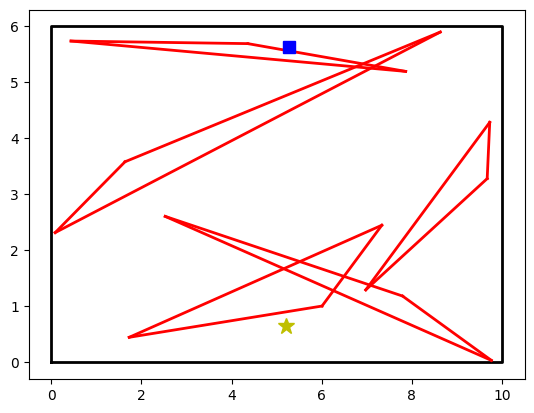

In [313]:
pl.ion()
np.random.seed(4)

# sizes
size_x = 10
size_y = 6
obs_counter = 5

# initiate
env = environment_2d.Environment(size_x, size_y, obs_counter)
pl.clf()
env.plot()
q = env.random_query()
if q is not None:
  x_start, y_start, x_goal, y_goal = q
  env.plot_query(x_start, y_start, x_goal, y_goal)

In [314]:
# GENERATE THE COORDINATES

n = 800
# generate n coordinates
rng = np.random.default_rng()
coords = rng.random((n, 2))

# resize coordinates
coords[:, 0] *= size_x
coords[:, 1] *= size_y

# remove if coordinates that collides with obstacle
mask = np.array([
    env.check_collision(x, y)
    for x, y in coords
])
coords = coords[~mask]

# add q_start and q_end to the coordinate list
q_start = np.array((q[0], q[1]))
q_end = np.array((q[2], q[3]))
final_coords = np.vstack((coords, q_start, q_end))

In [315]:
# HELPER
def collision_free(p1, p2):
	for region in env.obs:
		# get obstacle segments
		c1 = (region.x0, region.y0)
		c2 = (region.x1, region.y1)
		c3 = (region.x2, region.y2)

		# test intersection
		if intersect(p1, p2, c1, c2) or intersect(p1, p2, c2, c3) or intersect(p1, p2, c3, c1):
			return False
	return True

def intersect(p1, p2, c1, c2):
	o1 = orientation(p1, p2, c1)  # where c1 is relative to p1-p2
	o2 = orientation(p1, p2, c2)  # where c2 is relative to p1-p2
	o3 = orientation(c1, c2, p1)  # where p1 is relative to c1-c2
	o4 = orientation(c1, c2, p2)  # where p2 is relative to c1-c2

	if o1 != o2 and o3 != o4:  # generally this implies p1-p2 intersects c1-c2
		return True
	if o1 == 0 and on_segment(p1, p2, c1):  # p1, p2, c1 are colinear and c1 lies on segment p1-p2
		return True
	if o2 == 0 and on_segment(p1, p2, c2):  # p1, p2, c2 are colinear and c2 lies on segment p1-p2
		return True
	if o3 == 0 and on_segment(c1, c2, p1):  # c1, c2, p1 are colinear and p1 lies on segment c1-c2
		return True
	if o4 == 0 and on_segment(c1, c2, p2):  # c1, c2, p2 are colinear and p2 lies on segment c1-c2
		return True


	return False  # not intersect

"""
use cross product to find orientation of ordered triplet (p, q, r)

cross product: (x1,y1) x (x2,y2) = x1y2 - y1x2

output:
	0: colinear
	1: clockwise
	2: counter-clockwise
"""
def orientation(p, q, r):
	val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])

	if val == 0:  # colinear
		return 0
	
	if val > 0:  # clockwise
		return 1
	
	if val < 0:  # counter-clockwise
		return 2
	
"""
when the three points p, q, r are colinear,
check if a point q lies on line segment 'pr'
"""
def on_segment(p, q, r):
	return (q[0] <= max(p[0], r[0])) and (q[0] >= min(p[0], r[0])) and (q[1] <= max(p[1], r[1])) and (q[1] >= min(p[1], r[1]))

**PRM**

In [316]:
# FIND CONNECTED PATHS

r = 0.5
full_graph = KDTree(final_coords)  # build all connections
neighbors = full_graph.query_ball_point(final_coords, r)  # find all neighbors within radius 

# build edges
edges_prm = []  # list of tuple of the indices of each edge
# @param: i is the given node, j is its neighbor 
for i, neighbor in enumerate(neighbors):
	for j in neighbor:
		if i < j and collision_free(final_coords[i], final_coords[j]):  # avoid duplicate undirected edges
			edges_prm.append((i,j))

In [317]:
from collections import deque

# adjacency list is the neighbors list

# build CC's using BFS
"""
BFS algorithm to traverse all nodes
"""
def bfs(adj, src, visited, res):
	q = deque()
	visited[src] = True
	q.append(src)
	
	while q:
		curr = q.popleft()
		res.append(curr)

		# visit all unvisited neighbors of current node
		for neighbor in adj[curr]:
			if not visited[neighbor]:
				visited[neighbor] = True
				q.append(neighbor)

"""
apply BFS for all nodes, handles disconnected graphs
output: a list of all connected components
"""
def get_connected_components(adj):
	n = len(adj)
	visited = [False] * n
	res = []

	# loop through all vertices in undirected graph
	for i in range(0, n):
		if not visited[i]:
			component = []
			bfs(adj, i, visited, component)
			res.append(component)

	return res

"""
check if two nodes are in the same connected components
output: return the connected component if it exists; return None otherwise

@params: n1 is index of first node, n2 is index of second node
"""
def check_two_nodes_belong(n1, n2, ccs):
	for cc in ccs:
		if n1 in cc and n2 in cc:
			return cc
	return None

In [318]:
# CHECK IF START AND GOAL IS IN THE SAME CONNECTED COMPONENT
q_start_idx = final_coords.shape[0] - 2
q_end_idx = final_coords.shape[0] - 1

path_found = check_two_nodes_belong(q_start_idx, q_end_idx, get_connected_components(neighbors))

# convert to numpy array
if path_found is None:
    path_prm = np.array([])
else:
	path_prm = final_coords[path_found]

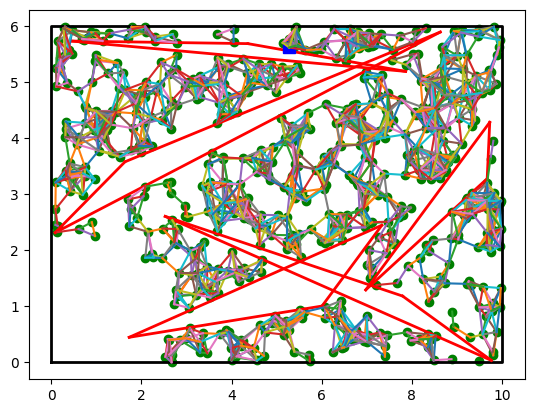

In [319]:
# PLOT THE PATH FOUND

# plot the given environment
pl.ion()
np.random.seed(4)

# sizes
size_x = 10
size_y = 6
obs_counter = 5

# initiate
env = environment_2d.Environment(size_x, size_y, obs_counter)
pl.clf()
env.plot()
q = env.random_query()
if q is not None:
  x_start, y_start, x_goal, y_goal = q
  env.plot_query(x_start, y_start, x_goal, y_goal)

# plot the connected component
comp_coords = final_coords[path_found]
pl.scatter(comp_coords[:, 0], comp_coords[:, 1], color='green')  # plot nodes

# plot edges
for node1, node2 in edges_prm:
	if path_found is not None:
		if node1 in path_found and node2 in path_found:
			pl.plot([final_coords[node1, 0], final_coords[node2, 0]], [final_coords[node1, 1], final_coords[node2, 1]])

**RRT**

In [320]:
def build_rrt(q_start, q_goal, size_x, size_y, max_iter, goal_radius, step_size):
	# initialize tree
	nodes = [q_start]
	parent = dict()
	parent[tuple(q_start)] = None

	rng = np.random.default_rng()

	for i in range(max_iter):
		# find random configuration to explore
		q_rand = np.array([rng.random() * size_x, rng.random() * size_y])

		q_new = extend(nodes, parent, q_rand, step_size)  # find the next node in tree

		# if there is a q_new, q_goal is within distance, and there is a collision free path connecting q_new and q_goal
		# add q_new and return the whole path
		if q_new is not None:
			if np.linalg.norm(q_new - q_goal) < goal_radius:
				if collision_free(q_new, q_goal):
					parent[tuple(q_goal)] = tuple(q_new)
					return extract_path(parent, q_goal)
	return None

def extend(nodes, parent, q_target, step_size):
	# find closest node in tree to branch towards q_target (which is q_rand)
	q_near = nearest(nodes, q_target)

	# find the next node to be inserted into the tree
	q_new = steer(q_near, q_target, step_size)

	if collision_free(q_near, q_new):
		nodes.append(q_new)
		parent[tuple(q_new)] = tuple(q_near)

		return q_new
	return None


def steer(q_near, q_target, r):
	dist = np.linalg.norm(q_target - q_near)

	if dist == 0:
		return None
	if dist <= r:
		return q_target
	else:
		return q_near + r * (q_target - q_near) / dist

"""
backtrack to find the tree path rrt
"""
def extract_path(parent, q_goal):
	path = []
	current = tuple(q_goal)

	while current is not None:  # traverse backwards until reaches root
		path.append(np.array(current))
		current = parent[current]
	
	path.reverse()
	return np.vstack(path)

def nearest(nodes, q_target):
	min_node = nodes[0]
	min_dist = np.linalg.norm(nodes[0] - q_target)
	for node in nodes:
		if np.linalg.norm(node - q_target) < min_dist:
			min_node = node
			min_dist = np.linalg.norm(node - q_target)
	return min_node

In [327]:
# BUILD RRT FOR THE GIVEN ENVIRONMENT
step_size = 0.5
max_iter = 5000
goal_radius = 0.5

path_rrt = build_rrt(q_start, q_end, size_x, size_y, max_iter, goal_radius, step_size)

In [340]:
# construct edges for rrt
edges_rrt = []
i = 0
while i <= len(path_rrt):
    edges_rrt.append((i, i+1))
    i += 1

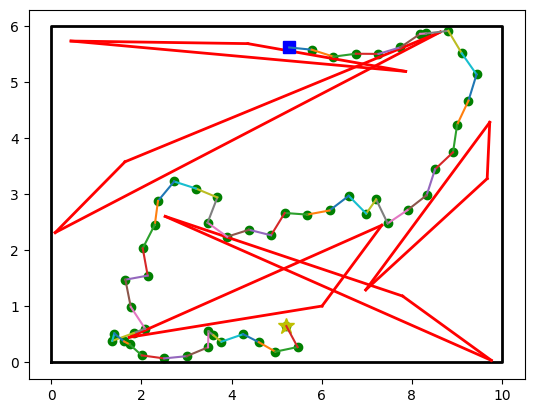

In [329]:
# PLOT RRT

# plot the given environment
pl.ion()
np.random.seed(4)

# sizes
size_x = 10
size_y = 6
obs_counter = 5

# initiate
env = environment_2d.Environment(size_x, size_y, obs_counter)
pl.clf()
env.plot()
q = env.random_query()
if q is not None:
  x_start, y_start, x_goal, y_goal = q
  env.plot_query(x_start, y_start, x_goal, y_goal)

if path_rrt is not None:
	# plot the connected component
	pl.scatter(path_rrt[:, 0], path_rrt[:, 1], color='green')  # plot nodes

	# plot edges
	for i, node1 in enumerate(path_rrt):
		try:
			node2 = path_rrt[i+1]
			pl.plot([node1[0], node2[0]], [node1[1], node2[1]])
		except IndexError:
			pass

**POST-PROCESSING**

Path-shortcutting

In [353]:
"""
path-shortcutting with straight lines for RRT
@params path is a 2D numpy array with the coords of all the nodes along a path
"""
def path_shortcutting(nodes, max_iter):
	rng = np.random.default_rng()
	for i in range(max_iter):
		if len(nodes) <= 2:
			break  # cannot further shortcut
		idx1, idx2 = rng.choice(len(nodes), size=2, replace=False)

		node1 = nodes[idx1]
		node2 = nodes[idx2]

		min_idx = min(idx1, idx2)
		max_idx = max(idx1, idx2)

		if collision_free(node1, node2):
			# remove unnecessary nodes
			new_nodes = np.vstack([nodes[:min_idx + 1], nodes[max_idx:]])
			nodes = new_nodes
	
	return np.array(nodes)

In [356]:
path_rrt_shortcutting = path_shortcutting(path_rrt, max_iter)

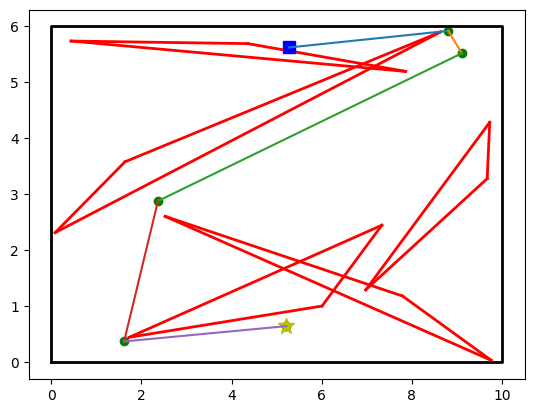

In [357]:
# PLOT RRT WITH SHORTCUT

# plot the given environment
pl.ion()
np.random.seed(4)

# sizes
size_x = 10
size_y = 6
obs_counter = 5

# initiate
env = environment_2d.Environment(size_x, size_y, obs_counter)
pl.clf()
env.plot()
q = env.random_query()
if q is not None:
  x_start, y_start, x_goal, y_goal = q
  env.plot_query(x_start, y_start, x_goal, y_goal)

if path_rrt_shortcutting is not None:
	# plot the connected component
	pl.scatter(path_rrt_shortcutting[:, 0], path_rrt_shortcutting[:, 1], color='green')  # plot nodes

	# plot edges
	for i, node1 in enumerate(path_rrt_shortcutting):
		try:
			node2 = path_rrt_shortcutting[i+1]
			pl.plot([node1[0], node2[0]], [node1[1], node2[1]])
		except IndexError:
			pass